**1**

In [6]:
%pip install -q pandas numpy matplotlib seaborn soundfile tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**2**

In [7]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

print("Libraries loaded.")

Libraries loaded.


**3**

In [8]:
# If this notebook is opened from the SHL_Audio project root, this should work.
PROJECT_DIR = Path.cwd().resolve()

# If VS Code is using a different working directory, set the full path manually:
# PROJECT_DIR = Path(r"D:/Your/Path/SHL_Audio")

DATA_DIR = PROJECT_DIR / "Dataset_Final"
TRAIN_AUDIO_DIR = DATA_DIR / "train"
TEST_AUDIO_DIR = DATA_DIR / "test"
FEATURE_DIR = PROJECT_DIR / "features"
OUTPUT_DIR = PROJECT_DIR / "outputs" 

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project folder: {PROJECT_DIR}")
print(f"Data folder exists: {DATA_DIR.is_dir()}")
print(f"Training audio folder exists: {TRAIN_AUDIO_DIR.is_dir()}")
print(f"Test audio folder exists: {TEST_AUDIO_DIR.is_dir()}")


Project folder: C:\Users\USER\Documents\Python Rep\SHL_Audio
Data folder exists: True
Training audio folder exists: True
Test audio folder exists: True


**4**

In [9]:
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"

for path in [TRAIN_CSV, TEST_CSV, SAMPLE_SUBMISSION_CSV]:
    if not path.is_file():
        raise FileNotFoundError(
            f"Could not find {path}. Check PROJECT_DIR and the data folder layout."
        )

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)

print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Sample-submission rows: {len(sample_submission_df):,}")

display(train_df.head())
display(test_df.head())
display(sample_submission_df.head())


Training rows: 769
Test rows: 216
Sample-submission rows: 204


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


**5**

In [10]:
required_train_columns = {"filename", "label"}
required_test_columns = {"filename"}
required_submission_columns = {"filename"}

if not required_train_columns.issubset(train_df.columns):
    raise ValueError(f"train.csv must contain columns: {sorted(required_train_columns)}")
if not required_test_columns.issubset(test_df.columns):
    raise ValueError(f"test.csv must contain columns: {sorted(required_test_columns)}")
if not required_submission_columns.issubset(sample_submission_df.columns):
    raise ValueError(
        f"sample_submission.csv must contain a 'filename' column. Found: {sample_submission_df.columns.tolist()}"
    )

table_checks = pd.DataFrame({
    "check": [
        "Missing training filenames",
        "Missing training labels",
        "Duplicate training filenames",
        "Missing test filenames",
        "Duplicate test filenames",
        "Duplicate sample-submission filenames",
        "Filename overlap between train and test CSVs",
    ],
    "count": [
        int(train_df["filename"].isna().sum()),
        int(train_df["label"].isna().sum()),
        int(train_df["filename"].duplicated().sum()),
        int(test_df["filename"].isna().sum()),
        int(test_df["filename"].duplicated().sum()),
        int(sample_submission_df["filename"].duplicated().sum()),
        len(set(train_df["filename"].dropna()) & set(test_df["filename"].dropna())),
    ],
})

display(table_checks)

,check,count
0,Missing training filenames,0
1,Missing training labels,0
2,Duplicate training filenames,0
3,Missing test filenames,0
4,Duplicate test filenames,0
5,Duplicate sample-submission filenames,0
6,Filename overlap between train and test CSVs,212


**6**

,value
count,769.000000
mean,3.313394
std,1.239000
min,0.000000
25%,2.500000
50%,3.000000
75%,4.000000
max,5.000000


Distinct labels, sorted:


,count
label,
0.0,37
1.0,1
1.5,3
2.0,102
2.5,79
3.0,174
3.5,64
4.0,124
4.5,52


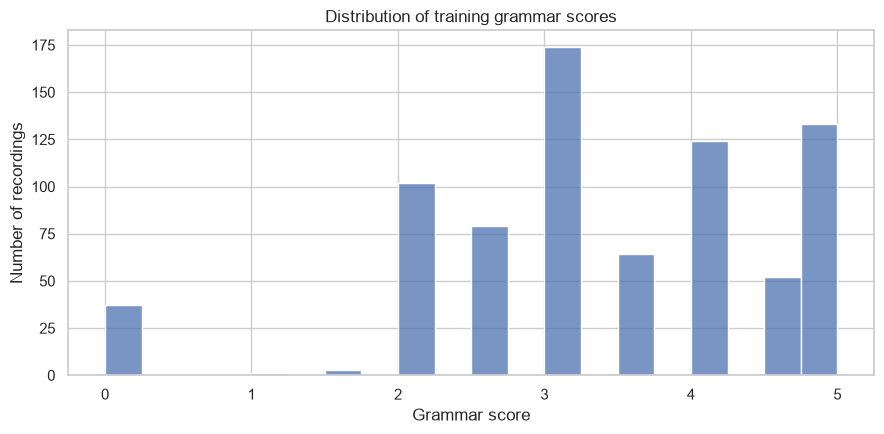

In [11]:
train_df["label"] = pd.to_numeric(train_df["label"], errors="coerce")

label_summary = train_df["label"].describe().to_frame("value")
display(label_summary)

print("Distinct labels, sorted:")
display(train_df["label"].value_counts(dropna=False).sort_index().rename("count").to_frame())

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(train_df["label"].dropna(), bins=20, kde=False, ax=ax)
ax.set(title="Distribution of training grammar scores", xlabel="Grammar score", ylabel="Number of recordings")
plt.tight_layout()
plt.show()

**7**

In [12]:
def resolve_audio_paths(filenames, audio_dir):
    return {str(name): audio_dir / str(name) for name in filenames if pd.notna(name)}

train_audio_paths = resolve_audio_paths(train_df["filename"], TRAIN_AUDIO_DIR)
test_audio_paths = resolve_audio_paths(test_df["filename"], TEST_AUDIO_DIR)

missing_train_audio = [name for name, path in train_audio_paths.items() if not path.is_file()]
missing_test_audio = [name for name, path in test_audio_paths.items() if not path.is_file()]

print(f"Training recordings missing from disk: {len(missing_train_audio)}")
print(f"Test recordings missing from disk: {len(missing_test_audio)}")

if missing_train_audio:
    display(pd.DataFrame({"missing_training_filename": missing_train_audio}).head(20))
if missing_test_audio:
    display(pd.DataFrame({"missing_test_filename": missing_test_audio}).head(20))

train_disk_files = {p.name for p in TRAIN_AUDIO_DIR.glob("*.wav")} if TRAIN_AUDIO_DIR.is_dir() else set()
test_disk_files = {p.name for p in TEST_AUDIO_DIR.glob("*.wav")} if TEST_AUDIO_DIR.is_dir() else set()

train_csv_names = set(train_df["filename"].dropna().astype(str))
test_csv_names = set(test_df["filename"].dropna().astype(str))

unreferenced_train_audio = sorted(train_disk_files - train_csv_names)
unreferenced_test_audio = sorted(test_disk_files - test_csv_names)

print(f"Unreferenced WAVs in training folder: {len(unreferenced_train_audio)}")
print(f"Unreferenced WAVs in test folder: {len(unreferenced_test_audio)}")

Training recordings missing from disk: 0
Test recordings missing from disk: 0
Unreferenced WAVs in training folder: 0
Unreferenced WAVs in test folder: 0


**8**

In [13]:
def inspect_audio(split, path_map):
    records = []
    for filename, path in tqdm(path_map.items(), desc=f"Inspecting {split} audio"):
        row = {"split": split, "filename": filename, "path": str(path), "exists": path.is_file()}
        if path.is_file():
            try:
                info = sf.info(str(path))
                row.update({
                    "duration_seconds": info.duration,
                    "sample_rate": info.samplerate,
                    "channels": info.channels,
                    "frames": info.frames,
                    "format": info.format,
                    "subtype": info.subtype,
                    "read_error": None,
                })
            except Exception as exc:
                row.update({
                    "duration_seconds": np.nan,
                    "sample_rate": np.nan,
                    "channels": np.nan,
                    "frames": np.nan,
                    "format": None,
                    "subtype": None,
                    "read_error": str(exc),
                })
        else:
            row.update({
                "duration_seconds": np.nan,
                "sample_rate": np.nan,
                "channels": np.nan,
                "frames": np.nan,
                "format": None,
                "subtype": None,
                "read_error": "File not found",
            })
        records.append(row)
    return pd.DataFrame(records)

train_audio_metadata = inspect_audio("train", train_audio_paths)
test_audio_metadata = inspect_audio("test", test_audio_paths)
audio_metadata = pd.concat([train_audio_metadata, test_audio_metadata], ignore_index=True)

display(audio_metadata.head())
display(
    audio_metadata.groupby("split").agg(
        recordings=("filename", "count"),
        found=("exists", "sum"),
        duration_min=("duration_seconds", "min"),
        duration_median=("duration_seconds", "median"),
        duration_max=("duration_seconds", "max"),
        sample_rates=("sample_rate", lambda values: sorted(values.dropna().unique().tolist())),
        channel_counts=("channels", lambda values: sorted(values.dropna().unique().tolist())),
        unreadable=("read_error", lambda values: int(values.notna().sum())),
    )
)

Inspecting train audio:   0%|          | 0/769 [00:00<?, ?it/s]

Inspecting test audio:   0%|          | 0/216 [00:00<?, ?it/s]

,split,filename,path,exists,duration_seconds,sample_rate,channels,frames,format,subtype,read_error
0,train,audio_192.wav,C:\Users\USER\Documents\Python Rep\SHL_Audio\Dataset_Final\train\audio_192.wav,True,60.508375,16000,1,968134,WAV,PCM_16,None
1,train,audio_436.wav,C:\Users\USER\Documents\Python Rep\SHL_Audio\Dataset_Final\train\audio_436.wav,True,60.074688,16000,1,961195,WAV,PCM_16,None
2,train,audio_447.wav,C:\Users\USER\Documents\Python Rep\SHL_Audio\Dataset_Final\train\audio_447.wav,True,60.074688,16000,1,961195,WAV,PCM_16,None
3,train,audio_126.wav,C:\Users\USER\Documents\Python Rep\SHL_Audio\Dataset_Final\train\audio_126.wav,True,45.060000,16000,1,720960,WAV,PCM_16,None
4,train,audio_61.wav,C:\Users\USER\Documents\Python Rep\SHL_Audio\Dataset_Final\train\audio_61.wav,True,45.300000,16000,1,724800,WAV,PCM_16,None


,recordings,found,duration_min,duration_median,duration_max,sample_rates,channel_counts,unreadable
split,,,,,,,,
test,216,216,6.48,45.060000,61.034687,[16000],[1],0
train,769,769,20.06,60.074688,61.040000,[16000],[1],0


**9**

In [ ]:
valid_durations = audio_metadata.dropna(subset=["duration_seconds"])

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(
    data=valid_durations,
    x="duration_seconds",
    hue="split",
    bins=25,
    element="step",
    stat="count",
    common_norm=False,
    ax=ax,
)
ax.set(title="Audio duration by split", xlabel="Duration (seconds)", ylabel="Number of recordings")
plt.tight_layout()
plt.show()

if not train_audio_metadata.empty:
    labelled_durations = train_audio_metadata.merge(
        train_df[["filename", "label"]], on="filename", how="left"
    ).dropna(subset=["duration_seconds", "label"])

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=labelled_durations, x="label", y="duration_seconds", ax=ax)
    ax.set(title="Recording duration across grammar scores", xlabel="Grammar score", ylabel="Duration (seconds)")
    plt.tight_layout()
    plt.show()